# How SDV Handles Null Values

When you pass data with missing values to SDV, nulls are handled **implicitly**, meaning you don't need to clean or impute them yourself. Under the hood, SDV's data transformation layer (RDT) preprocesses nulls before they reach the synthesizer, and then reintroduces them into the synthetic output.

This cookbook walks through exactly what happens at each stage, common misconceptions, and how to customize the behavior when defaults aren't enough for your use case.

## 0. Install the required packages.

In [1]:
%pip install sdv -q

/Users/nemanjavujic/Desktop/datacebo/datacebo-cookbook/tutorials/null_values/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## 1. Load the Dataset

We will load the `null_values_demo_dataset` dataset. This is a single-table dataset crafted for this cookbook, it has different amounts of missing values all columns.

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sdv.datasets.demo import download_demo
from rdt.transformers.pii import AnonymizedFaker

data, metadata = download_demo(
    modality='single_table',
    dataset_name='null_values_demo_dataset'
)

data.head()

,ticket_id,created_at,customer_email,priority,category,is_escalated,response_time_hours,resolution_time_hours,satisfaction_score,internal_notes_count,resolved_at,resolution_status,agent_name,response_time_legacy,customer_phone,num_reassignments,customer_notes
0,TKT-00000,2025-09-26 12:36:44,james.davis@gmail.com,Medium,Technical,False,1.61,NaN,NaN,NaN,NaN,NaN,NaN,1.61,(713) 584-8784,1.0,NaN
1,TKT-00001,2025-07-06 06:41:18,linda.jones_760@gmail.com,Critical,Billing,False,0.95,3.05,NaN,NaN,2025-07-06 09:44:18,Resolved,Derek Patel,0.95,(206) 459-3081,3.0,NaN
2,TKT-00002,2025-09-27 23:57:30,NaN,Critical,Technical,False,4.50,14.60,NaN,NaN,2025-09-28 14:33:30,Workaround,Raymond Reddington,4.50,(415) 598-6575,0.0,NaN
3,TKT-00003,2025-11-07 20:42:47,patricia.miller@outlook.com,Medium,Feature Request,False,NaN,17.29,3.0,NaN,2025-11-08 14:00:11,Resolved,Marko Zakic,-1.00,NaN,2.0,NaN
4,TKT-00004,2025-09-02 00:03:08,michael.wilson@gmail.com,Medium,Bug Report,NaN,1.61,34.52,NaN,NaN,2025-09-03 10:34:20,Workaround,Raymond Reddington,1.61,(310) 613-5736,1.0,NaN


Let's take a look at how many null values are present in the data.

In [3]:
data.isnull().mean().round(3)

ticket_id                0.000
created_at               0.000
customer_email           0.101
priority                 0.000
category                 0.146
is_escalated             0.200
response_time_hours      0.049
resolution_time_hours    0.305
satisfaction_score       0.684
internal_notes_count     0.928
resolved_at              0.305
resolution_status        0.305
agent_name               0.078
response_time_legacy     0.000
customer_phone           0.252
num_reassignments        0.195
customer_notes           1.000
dtype: float64

This dataset has columns with null rates ranging from 0% to 100%. Let's take a look with a simple visualization:

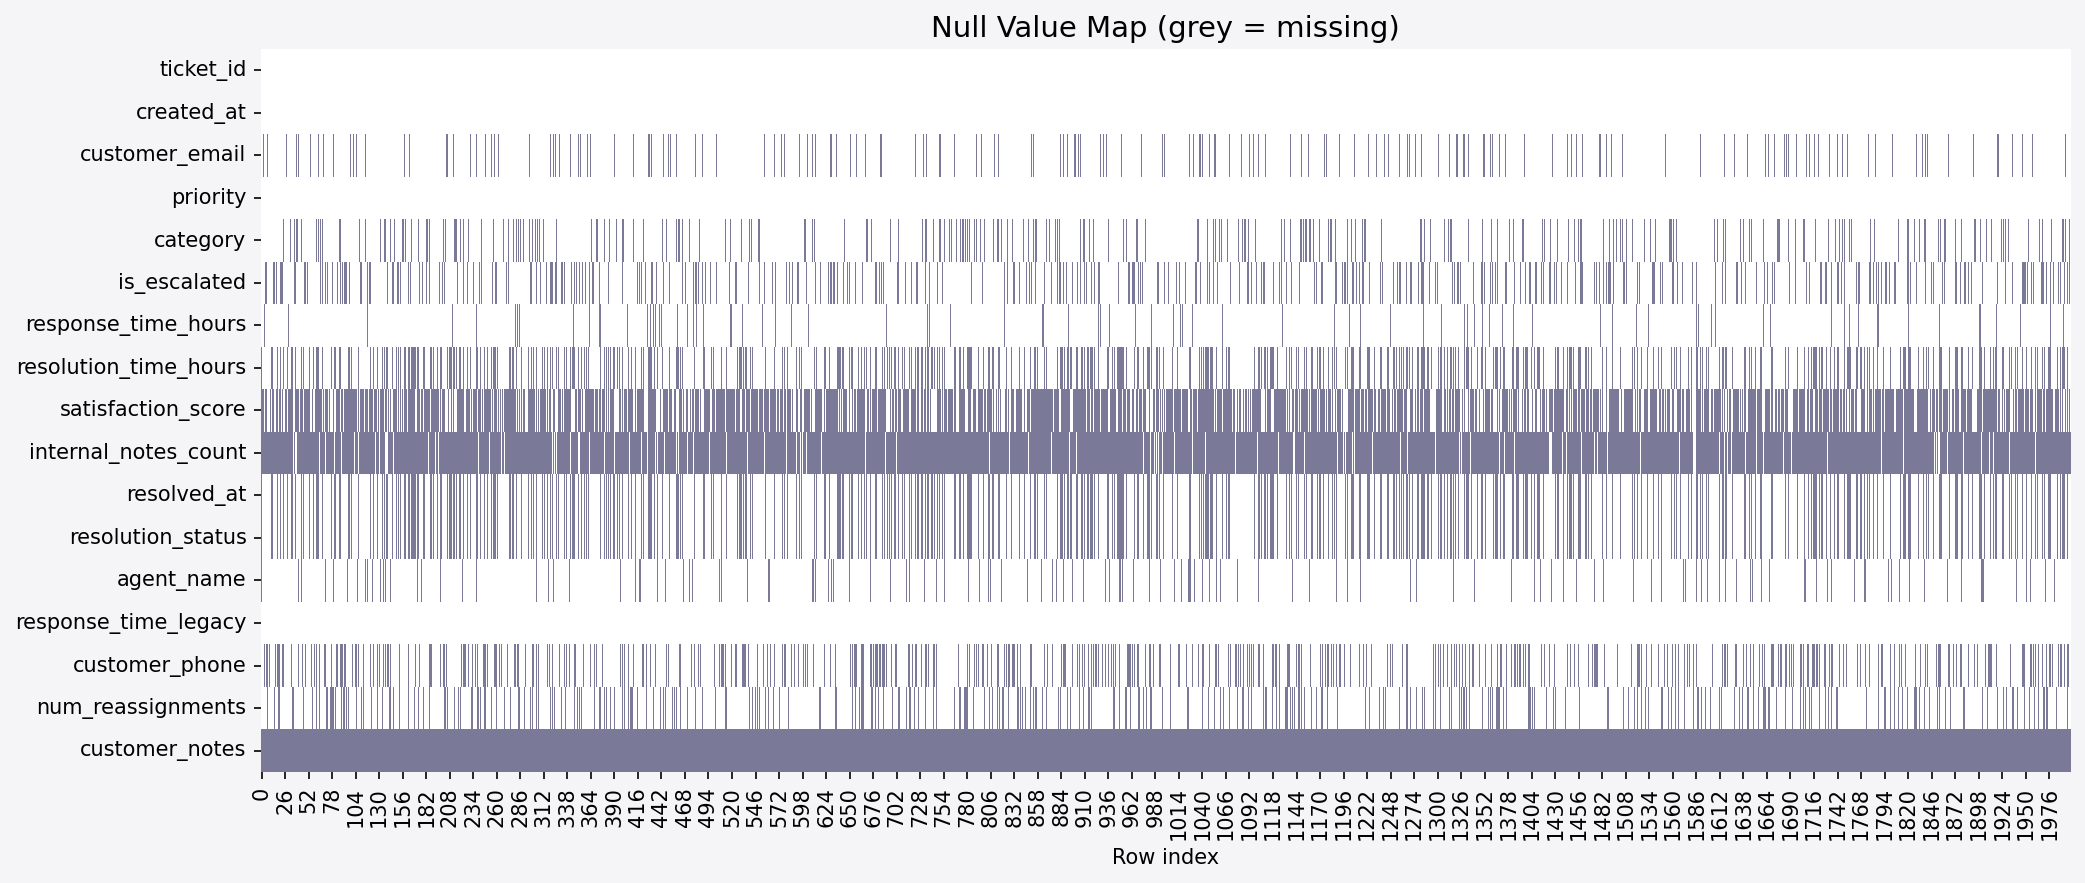

## 2. The Hidden Binary Indicator Column

SDV handles nulls during preprocessing. Specifically, there are two approaches in which preprocessing handles null values by specifying the `missing_value_generation` parameter:

- **`'from_column'`**: [RDT](https://docs.sdv.dev/rdt), which is SDV's reversible data transformation library, creates a hidden **binary `.is_null` column** for each nullable column. For example, `response_time_hours` gets a companion column `response_time_hours.is_null` (0 = present, 1 = missing). These get fed into the synthesizer so it learns *when* values should be null based on other features. This increases the total column count.

- **`'random'`**: SDV does **not** create any extra columns for nulls. The synthesizer never sees which rows were null — nulls are replaced with imputed values before the synthesizer trains, and the null positions are discarded. After sampling, nulls are reintroduced randomly at the original column-level rate. During preprocessing, PII columns (email, phone, name) and IDs are handled separately, so the column count actually *decreases*.

Let's see the difference:

### Helper Function

The `phone_transformer()` helper returns a fresh `AnonymizedFaker` instance each time it is called. This is needed for Enterprise compatibility, since transformers can only be fit once and must be re-instantiated between synthesizer fits.

In [4]:
# Helper to override the phone transformer for Enterprise compatibility.
# Returns a fresh instance each time since transformers can only be fit once.
def phone_transformer():
    return {'customer_phone': AnonymizedFaker(provider_name='phone_number', function_name='phone_number')}

In [5]:
from sdv.single_table import GaussianCopulaSynthesizer
from rdt.transformers.numerical import FloatFormatter
from rdt.transformers.datetime import UnixTimestampEncoder

# Default 'random' (no .is_null columns)
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.auto_assign_transformers(data)
synthesizer.update_transformers(phone_transformer())
synthesizer.fit(data)

ht_default = synthesizer._data_processor._hyper_transformer
transformed_default = ht_default.transform(data)

is_null_default = [c for c in transformed_default.columns if '.is_null' in str(c)]
print(f'=== Default (random) ===')
print(f'Original columns:     {data.shape[1]}')
print(f'Transformed columns:  {transformed_default.shape[1]}  (PII and ID columns handled separately)')
print(f'.is_null columns:     {len(is_null_default)}')

# Keep a reference for later sections
preprocessed = transformed_default

=== Default (random) ===
Original columns:     17
Transformed columns:  13  (PII and ID columns handled separately)
.is_null columns:     0


Now let's set up a synthesizer using `'from_column'` mode and compare the column counts:

In [6]:
# from_column mode: .is_null columns appear
fc_synthesizer = GaussianCopulaSynthesizer(metadata, enforce_rounding=False)
fc_synthesizer.auto_assign_transformers(data)
fc_synthesizer.update_transformers(phone_transformer())

nullable_numerical = [
    'response_time_hours', 'resolution_time_hours', 'satisfaction_score',
    'internal_notes_count', 'num_reassignments', 'response_time_legacy'
]
fc_synthesizer.update_transformers({
    col: FloatFormatter(missing_value_replacement='mean', missing_value_generation='from_column')
    for col in nullable_numerical
})
fc_synthesizer.update_transformers({
    'resolved_at': UnixTimestampEncoder(missing_value_generation='from_column'),
})

fc_synthesizer.fit(data)

ht_fc = fc_synthesizer._data_processor._hyper_transformer
transformed_fc = ht_fc.transform(data)

is_null_fc = [c for c in transformed_fc.columns if '.is_null' in str(c)]
print(f'=== from_column ===')
print(f'Transformed columns:  {transformed_fc.shape[1]}  (includes .is_null indicators)')
print(f'.is_null columns:     {len(is_null_fc)}')
for c in is_null_fc:
    print(f'  {c}')

=== from_column ===
Transformed columns:  19  (includes .is_null indicators)
.is_null columns:     6
  response_time_hours.is_null
  resolution_time_hours.is_null
  satisfaction_score.is_null
  internal_notes_count.is_null
  resolved_at.is_null
  num_reassignments.is_null


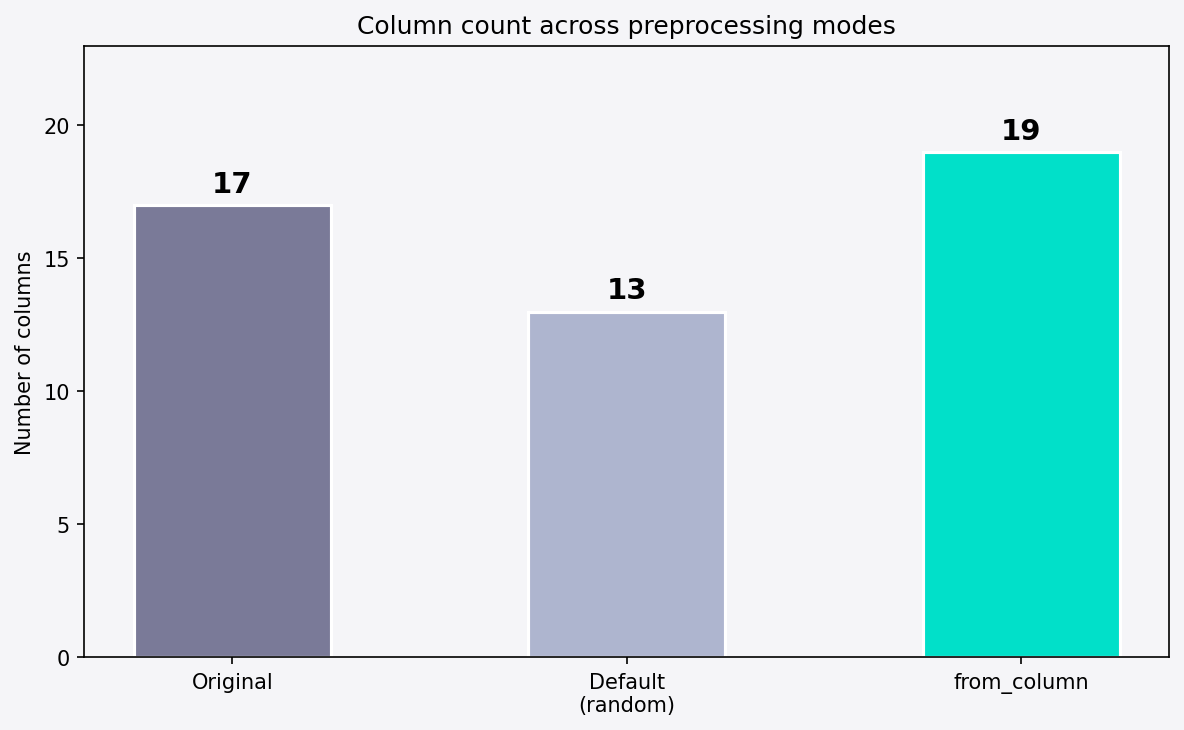

## 3. Missing Value Replacement

Before the data reaches the synthesizer, nulls need to be replaced with actual numbers. The `missing_value_replacement` parameter controls what that fill value is.

The default for most transformers is `'mean'`, which equates to every null being replaced with the column's mean value. This directly affects what the model learns: if a column has 40% nulls, the model sees 40% of values clustered at the mean.

Let's see this in action with `response_time_hours` (~5% null):

In [7]:
col = 'response_time_hours'
mean_val = data[col].mean(skipna=True)

# Find the preprocessed column name for response_time_hours
preproc_col = [c for c in preprocessed.columns if col in str(c) and '.is_null' not in str(c)][0]
preprocessed_values = preprocessed[preproc_col]

print(f'Null count in original:      {data[col].isnull().sum()}')
print(f'Values exactly at mean in preprocessed: {(preprocessed_values == mean_val).sum()}')

Null count in original:      98
Values exactly at mean in preprocessed: 98


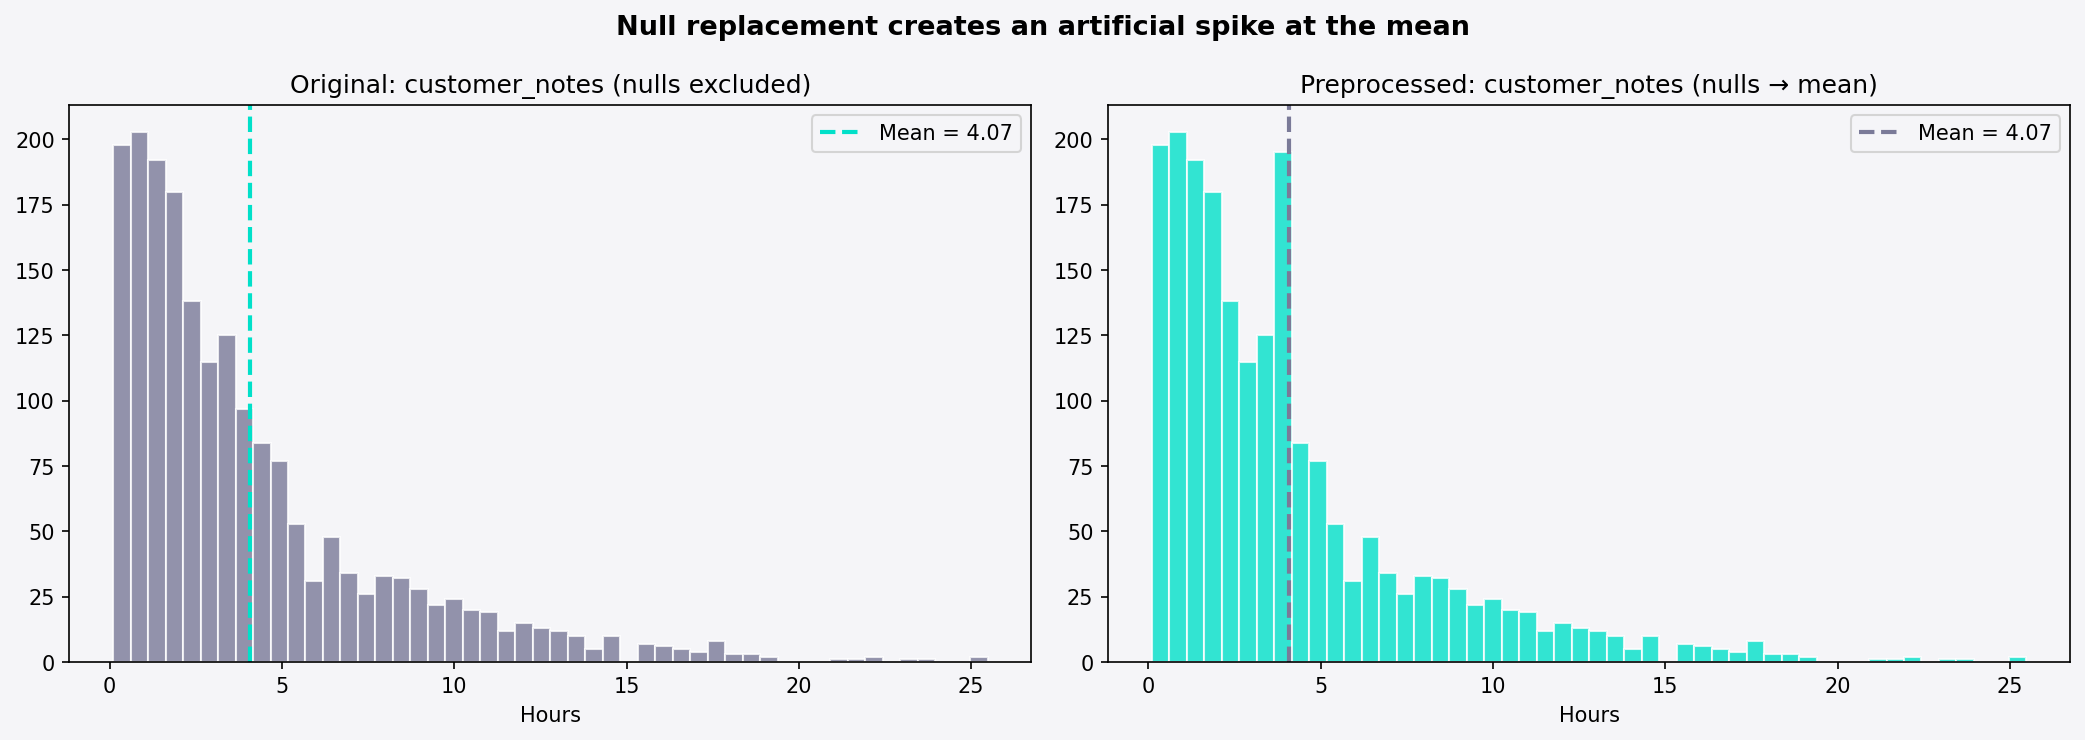

> **Key takeaway:** The default `'mean'` replacement creates an artificial cluster of values at the mean. For columns with high null rates, this can significantly distort the learned distribution. Consider using `'random'` replacement instead, which samples from existing non-null values.

## 4. Missing Value Generation

After the model generates new synthetic data, the reverse transform needs to decide which synthetic values should be turned back into nulls. The `missing_value_generation` parameter controls this:

- **`'random'`**: Randomly assigns nulls at roughly the same overall rate as the original data. Does NOT consider whether a particular row "should" be null based on other columns.
- **`'from_column'`**: Uses the modeled `.is_null` binary column. The model learned *when* values should be null based on other features, so this preserves correlations - but can underproduce nulls (more on that in Section 8).
- **`None`**: Never recreates nulls **for columns where you configure it**. Numerical and datetime columns will have zero missing values. However, categorical and boolean columns handle nulls as a category by design, so they preserve their null rate regardless of this setting. PII columns (email, phone, name) also independently preserve their null rate. To get truly zero nulls across *all* columns, you'd need to configure every column type individually - or clean nulls from your source data.

Let's sample with all three modes and compare null rates side-by-side:

In [8]:
# --- 'random' (default) --- already fitted as `synthesizer` in cell above
synthetic_data = synthesizer.sample(num_rows=2000)

# --- 'from_column' --- already fitted as `fc_synthesizer` in cell above
synthetic_fc = fc_synthesizer.sample(num_rows=2000)

# --- None (no nulls) ---
from rdt.transformers.numerical import FloatFormatter as FF
from rdt.transformers.datetime import UnixTimestampEncoder as UTE
from rdt.transformers.categorical import LabelEncoder as LE

none_synth = GaussianCopulaSynthesizer(metadata)
none_synth.auto_assign_transformers(data)
none_synth.update_transformers(phone_transformer())
none_synth.update_transformers({
    col: FF(missing_value_replacement='mean', missing_value_generation=None)
    for col in ['response_time_hours', 'resolution_time_hours', 'satisfaction_score',
                'internal_notes_count', 'num_reassignments', 'response_time_legacy']
})
none_synth.update_transformers({
    'resolved_at': UTE(missing_value_generation=None),
})
none_synth.fit(data)
synthetic_none = none_synth.sample(num_rows=2000)

# Compare null rates across all three modes
null_comparison = pd.DataFrame({
    'Real': data.isnull().mean().round(3),
    'random': synthetic_data.isnull().mean().round(3),
    'from_column': synthetic_fc.isnull().mean().round(3),
    'None': synthetic_none.isnull().mean().round(3),
})
null_comparison[null_comparison['Real'] > 0]

,Real,random,from_column,None
customer_email,0.101,0.101,0.101,0.101
category,0.146,0.132,0.140,0.132
is_escalated,0.200,0.206,0.212,0.206
response_time_hours,0.049,0.044,1.000,0.000
resolution_time_hours,0.305,0.306,0.316,0.000
satisfaction_score,0.684,0.664,0.678,0.000
internal_notes_count,0.928,0.925,0.990,0.000
resolved_at,0.305,0.314,0.316,0.000
resolution_status,0.305,0.294,0.318,0.294
agent_name,0.078,0.078,0.078,0.078


> **Notice the `response_time_hours` row:** `from_column` shows 100% null rate vs 4.9% real. This is a known issue with GaussianCopula modeling binary indicator columns - we explore it in detail in Section 8. The default `'random'` mode does not have this problem.
>
> Also note the `None` column: categorical columns (`category`, `is_escalated`, `resolution_status`), PII columns (`customer_email`, `agent_name`, `customer_phone`), and the all-null `customer_notes` still show nulls. This is because `missing_value_generation=None` was only configured on numerical and datetime columns - see the explanation in Section 4 above.

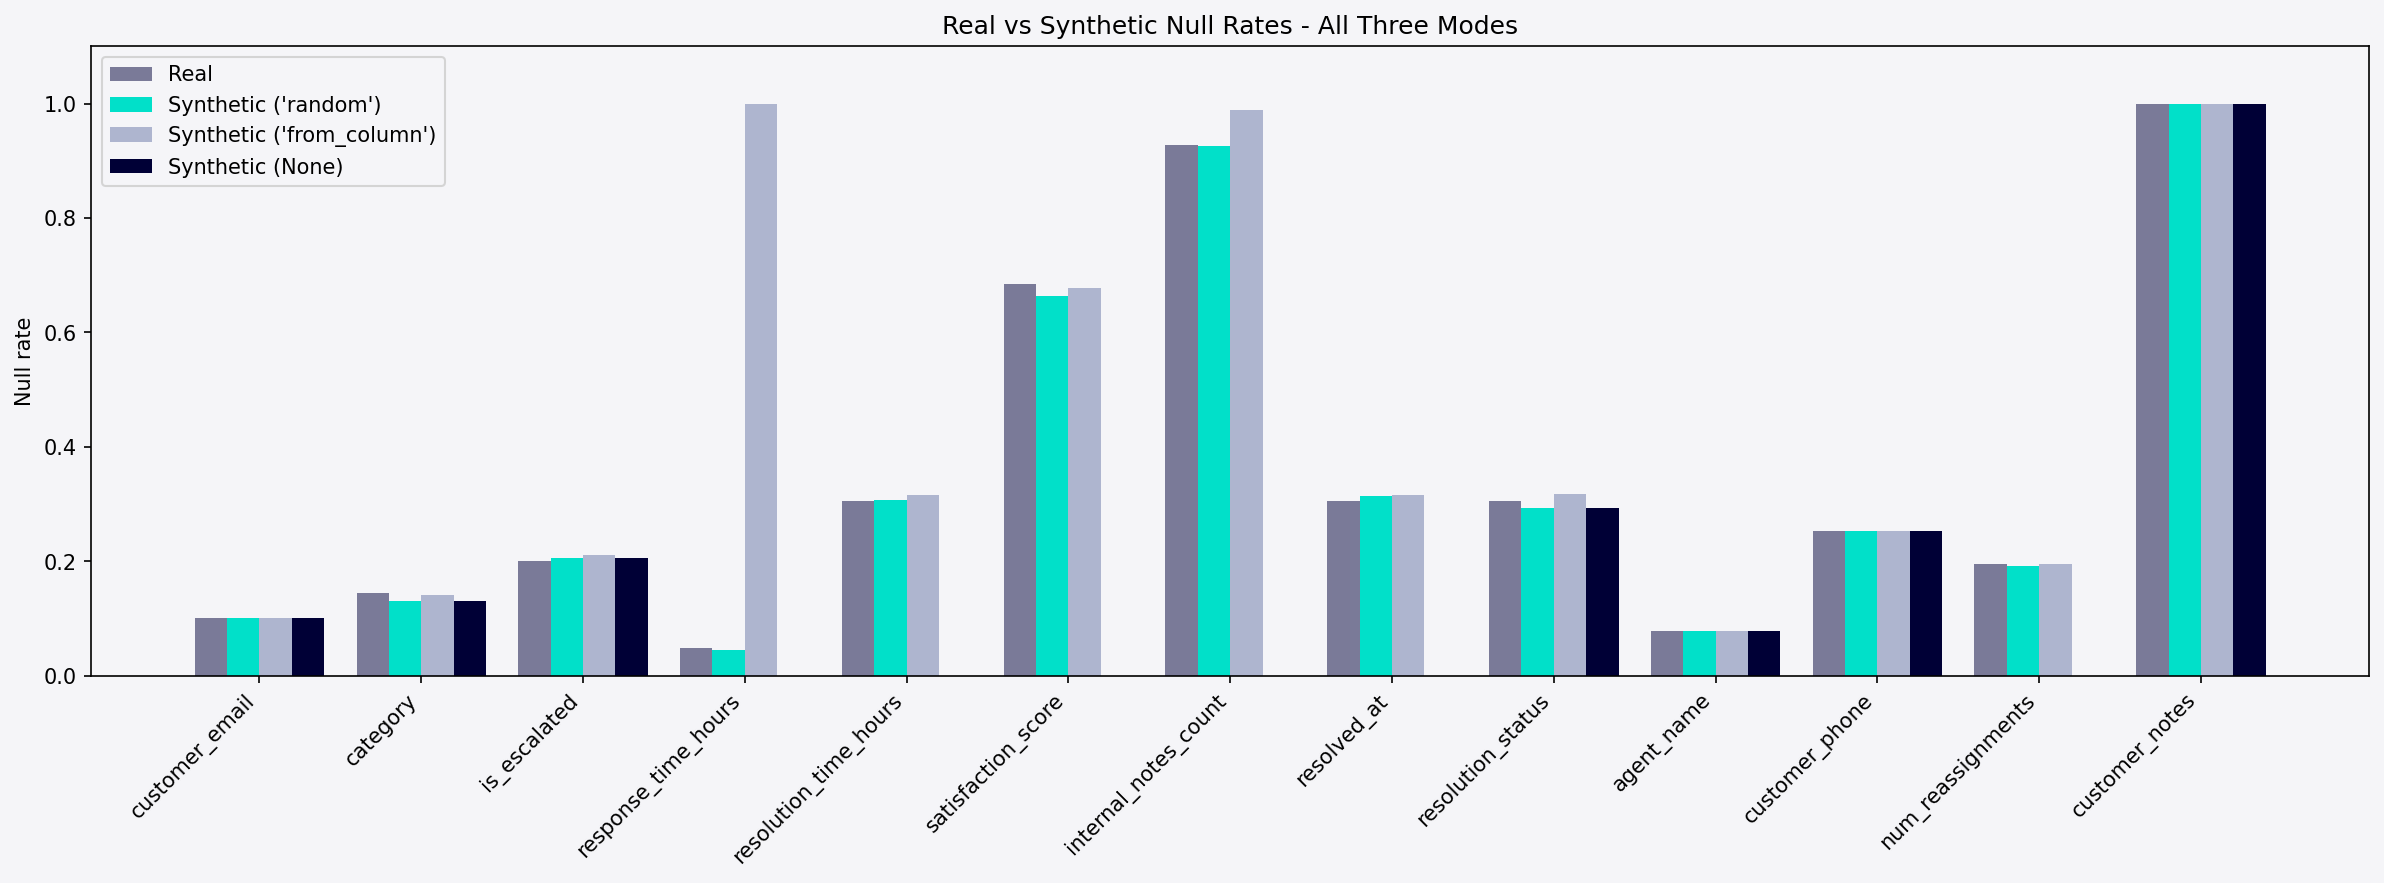

## 5. Null Handling by sdtype

Different column types (sdtypes) handle nulls differently under the hood. Let's see what transformers SDV assigned to each column:

In [9]:
transformers = synthesizer.get_transformers()
for col_name, transformer in transformers.items():
    null_rate = data[col_name].isnull().mean()
    print(f'{col_name:30s} | {type(transformer).__name__:30s} | null rate: {null_rate:.1%}')

ticket_id                      | RegexGenerator                 | null rate: 0.0%
created_at                     | UnixTimestampEncoder           | null rate: 0.0%
customer_email                 | AnonymizedFaker                | null rate: 10.1%
priority                       | UniformEncoder                 | null rate: 0.0%
category                       | UniformEncoder                 | null rate: 14.5%
is_escalated                   | UniformEncoder                 | null rate: 20.1%
response_time_hours            | FloatFormatter                 | null rate: 4.9%
resolution_time_hours          | FloatFormatter                 | null rate: 30.5%
satisfaction_score             | FloatFormatter                 | null rate: 68.4%
internal_notes_count           | FloatFormatter                 | null rate: 92.8%
resolved_at                    | UnixTimestampEncoder           | null rate: 30.5%
resolution_status              | UniformEncoder                 | null rate: 30.5%
agent_na

### How each sdtype handles nulls:

| sdtype | Transformer | Null handling |
|--------|------------|---------------|
| **numerical** | `FloatFormatter` | Fills nulls with mean (default). Creates `.is_null` column only when `missing_value_generation='from_column'`. |
| **categorical** | `UniformEncoder` | Encodes each category as a random uniform float. Null is treated as just another category - no `.is_null` column needed. |
| **boolean** | `UniformEncoder` | Same as categorical - null becomes a third value alongside True/False, encoded as a uniform float. |
| **datetime** | `UnixTimestampEncoder` | Converts to epoch seconds, then handles like numerical. Creates `.is_null` column with `'from_column'`. |
| **email/phone/name** (PII) | `AnonymizedFaker` | Regenerates values using Faker. Nulls reintroduced randomly at original rate (default). Supports `'from_column'` for indicator-based null modeling. |
| **id** (primary key) | `RegexGenerator` | **Cannot have nulls.** SDV will error if the primary key contains missing values. |

### Null Handling Across Synthesizers

All single-table synthesizers (GaussianCopula, CTGAN, TVAE, CopulaGAN) share the exact same RDT preprocessing pipeline for null handling. The synthesizer never sees a null value regardless of which synthesizer you choose.

One difference worth noting: CTGAN and TVAE handle categorical columns internally (bypassing RDT's `UniformEncoder`), but the null behavior remains the same - null is treated as another category value.

In [10]:
from sdv.single_table import CTGANSynthesizer

ctgan = CTGANSynthesizer(metadata, epochs=5)  # low epochs for demo speed
ctgan.auto_assign_transformers(data)
ctgan.update_transformers(phone_transformer())
ctgan.fit(data)
ctgan_synthetic = ctgan.sample(num_rows=2000)

# Compare null rates: GaussianCopula vs CTGAN
null_compare = pd.DataFrame({
    'Real': data.isnull().mean().round(3),
    'GaussianCopula': synthetic_data.isnull().mean().round(3),
    'CTGAN': ctgan_synthetic.isnull().mean().round(3),
})
null_compare[null_compare['Real'] > 0]

,Real,GaussianCopula,CTGAN
customer_email,0.101,0.101,0.101
category,0.146,0.132,0.134
is_escalated,0.200,0.206,0.278
response_time_hours,0.049,0.044,0.044
resolution_time_hours,0.305,0.306,0.306
satisfaction_score,0.684,0.664,0.664
internal_notes_count,0.928,0.925,0.925
resolved_at,0.305,0.314,0.314
resolution_status,0.305,0.294,0.268
agent_name,0.078,0.078,0.078


## 6. The Placeholder Gotcha

A common real-world pattern is using placeholder values like `-1`, `999`, or `"N/A"` instead of actual null values. **SDV does not detect these as missing.** It treats them as legitimate data points.

Our dataset has two versions of response time:
- `response_time_hours`: Uses proper `NaN` for missing values (~5% null)
- `response_time_legacy`: Uses `-1.0` as a placeholder (0% null from SDV's perspective)

In [11]:
print('response_time_hours:')
print(f'  Null count: {data["response_time_hours"].isnull().sum()}')
print(f'  Min value:  {data["response_time_hours"].min():.2f}')
print()
print('response_time_legacy:')
print(f'  Null count: {data["response_time_legacy"].isnull().sum()}')
print(f'  -1 count:   {(data["response_time_legacy"] == -1.0).sum()}')
print(f'  Min value:  {data["response_time_legacy"].min():.2f}')

response_time_hours:
  Null count: 98
  Min value:  0.10

response_time_legacy:
  Null count: 0
  -1 count:   98
  Min value:  -1.00


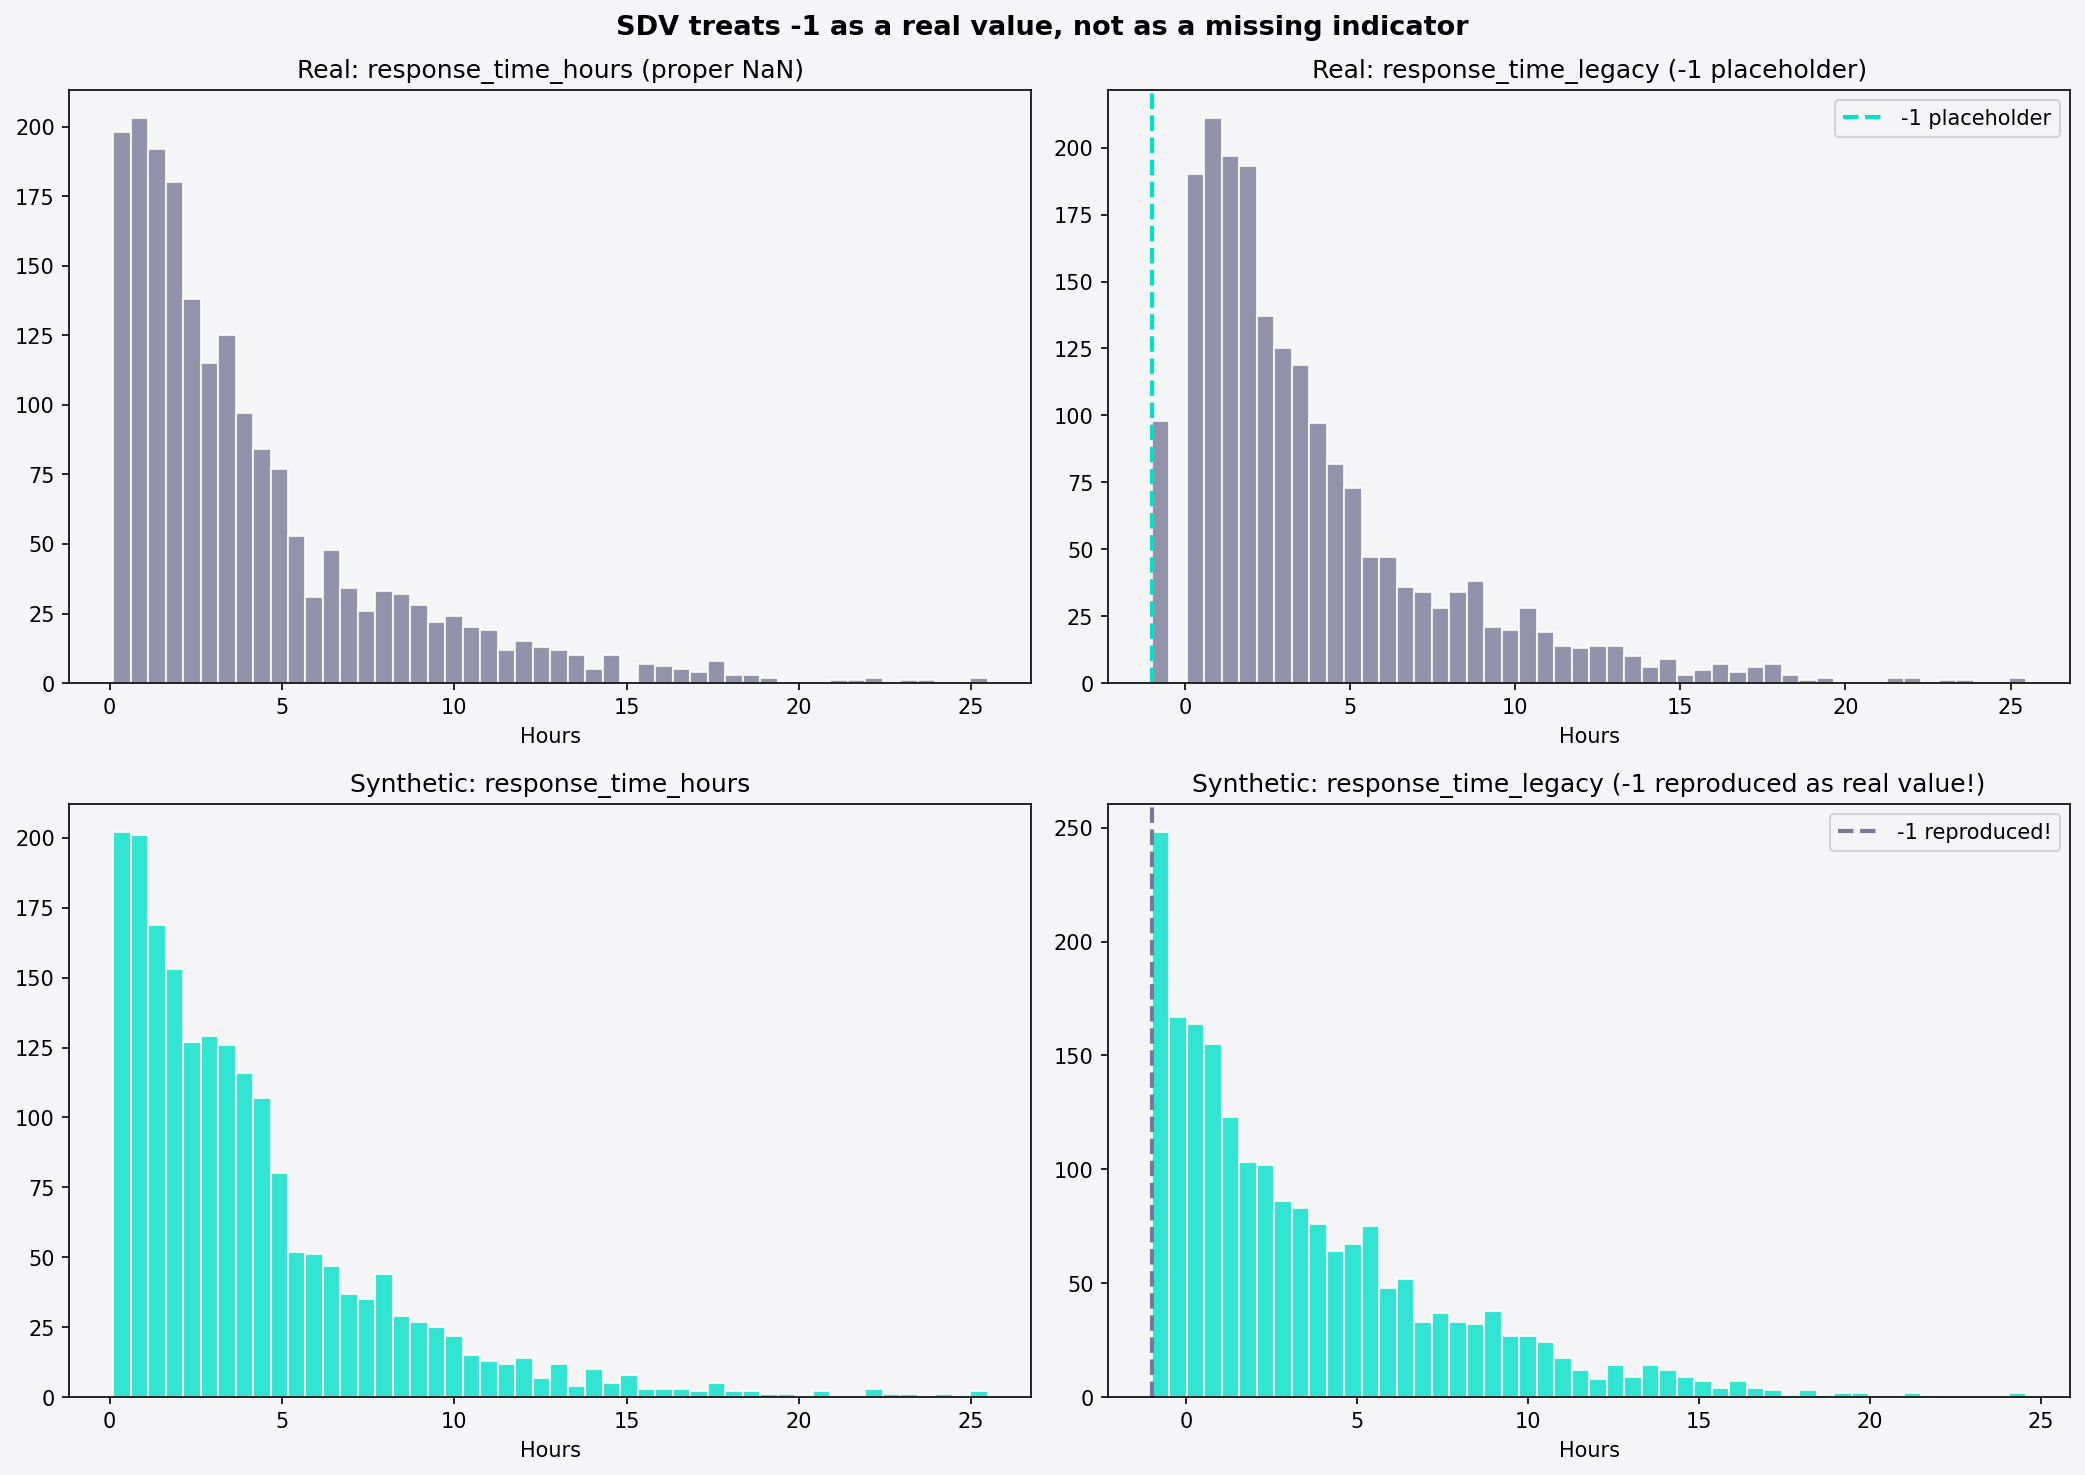

> **Key takeaway:** Always replace placeholder values with `NaN` before passing data to SDV. Otherwise SDV will model them as real values and reproduce them in the synthetic output.
>
> **Also watch for empty strings.** SDV uses `pd.isna()` to detect nulls, which does NOT flag empty strings `""` as missing. If your data uses empty strings to represent missing values (common in CSV imports), convert them before fitting:
> ```python
> data = data.replace('', np.nan)
> ```

## 7. Correlated Nulls

In our dataset, three columns are always null or non-null together:
- `resolution_time_hours`
- `resolved_at`
- `resolution_status`

These represent unresolved tickets - if a ticket isn't resolved, all three fields are missing. This is a **correlated null pattern**.

By default, SDV's `'random'` null generation treats each column independently, which **breaks this correlation** in the synthetic data.

In [12]:
correlated_cols = ['resolution_time_hours', 'resolved_at', 'resolution_status']

# Real data: check if nulls are always aligned
real_null_pattern = data[correlated_cols].isnull()
real_all_same = (real_null_pattern.nunique(axis=1) == 1).all()
print(f'Real data - nulls always aligned across correlated columns: {real_all_same}')

# Synthetic data: check if nulls are still aligned
synth_null_pattern = synthetic_data[correlated_cols].isnull()
synth_all_same = (synth_null_pattern.nunique(axis=1) == 1).all()
print(f'Synthetic data - nulls always aligned: {synth_all_same}')

if not synth_all_same:
    misaligned = (synth_null_pattern.nunique(axis=1) > 1).sum()
    print(f'  Rows with broken correlation: {misaligned} / {len(synthetic_data)}')

Real data - nulls always aligned across correlated columns: True
Synthetic data - nulls always aligned: False
  Rows with broken correlation: 1274 / 2000


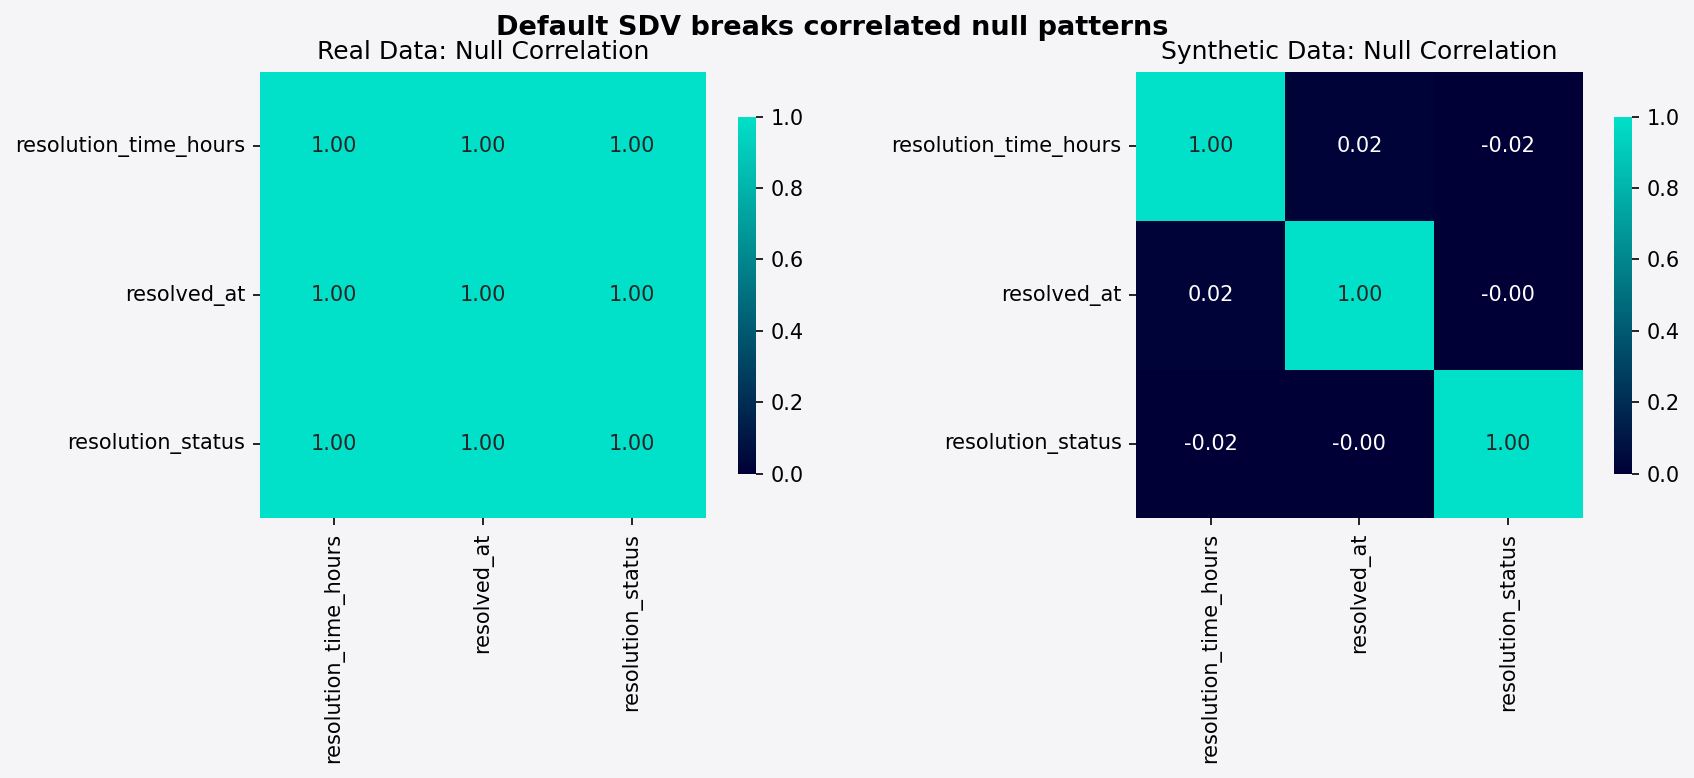

> **Key takeaway:** If your data has columns where nulls are correlated (e.g., always null together), you have three options:
> - `missing_value_generation='from_column'` - reduces misalignment but doesn't guarantee it (as shown in Section 11)
> - `FixedCombinations` constraint - strictly enforces the pattern, but also locks non-null value combinations
> - `FixedNullCombinations` constraint (Enterprise) - purpose-built for this: enforces null co-occurrence without restricting non-null value permutations

## 8. GaussianCopula Null Rate Distortion with `from_column`

When you use `missing_value_generation='from_column'`, the GaussianCopula must model a **binary** `.is_null` column using a **continuous** Gaussian distribution. This mismatch means the model often produces null rates that are wildly different from the original data - sometimes underproducing nulls, sometimes overproducing them.

This is NOT an issue with the default `'random'` mode (which just assigns nulls at the original rate without modeling). It only appears when you opt into `'from_column'`.

We already sampled both modes in Section 4. Let's compare them directly on the high-null columns:

In [13]:
compare_cols = ['response_time_hours', 'resolution_time_hours', 'satisfaction_score',
                'internal_notes_count', 'num_reassignments']

for col in compare_cols:
    real_rate = data[col].isnull().mean()
    random_rate = synthetic_data[col].isnull().mean()
    fc_rate = synthetic_fc[col].isnull().mean()
    print(f'{col}:')
    print(f'  Real null rate:          {real_rate:.1%}')
    print(f'  random (default):        {random_rate:.1%}  (diff: {random_rate - real_rate:+.1%})')
    print(f'  from_column:             {fc_rate:.1%}  (diff: {fc_rate - real_rate:+.1%})')
    print()

response_time_hours:
  Real null rate:          4.9%
  random (default):        4.5%  (diff: -0.5%)
  from_column:             100.0%  (diff: +95.1%)

resolution_time_hours:
  Real null rate:          30.5%
  random (default):        30.6%  (diff: +0.2%)
  from_column:             31.6%  (diff: +1.1%)

satisfaction_score:
  Real null rate:          68.4%
  random (default):        66.4%  (diff: -2.0%)
  from_column:             67.8%  (diff: -0.7%)

internal_notes_count:
  Real null rate:          92.8%
  random (default):        92.5%  (diff: -0.2%)
  from_column:             99.0%  (diff: +6.2%)

num_reassignments:
  Real null rate:          19.5%
  random (default):        19.2%  (diff: -0.3%)
  from_column:             19.6%  (diff: +0.1%)



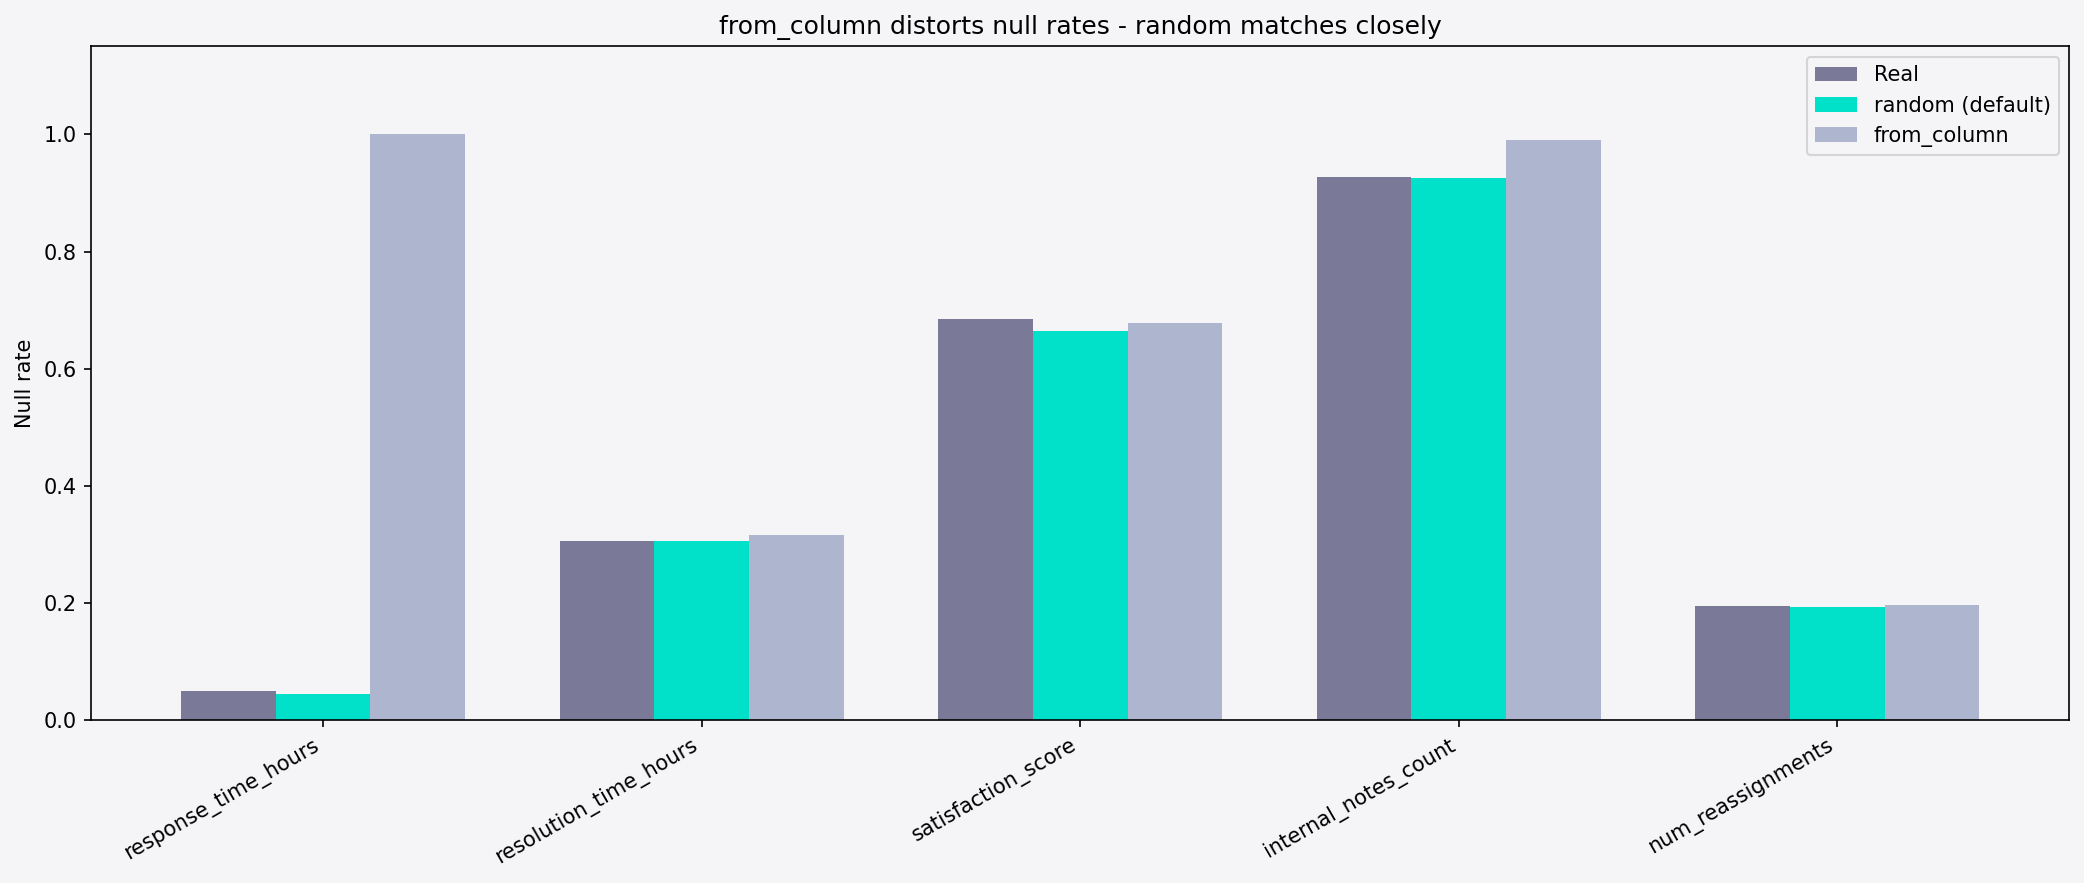

> **Key takeaway:** The default `'random'` mode reproduces null rates accurately. If you switch to `'from_column'` to preserve null correlations (Section 7), be aware that GaussianCopula can wildly distort null rates. Always compare `data.isnull().mean()` vs `synthetic_data.isnull().mean()` after sampling.

## 9. The All-Null Column Edge Case

The `customer_notes` column is 100% null - every single value is missing. With the default `UniformEncoder`, this column gets encoded as **random uniform floats** between 0 and 1. The model trains on pure noise.

The synthetic output is still 100% null because during reverse transform, the only known "category" is null - so everything maps back to null regardless of what the model generates.

In [14]:
print('customer_notes in original data:')
print(f'  Null rate: {data["customer_notes"].isnull().mean():.0%}')
print(f'  Unique values: {data["customer_notes"].nunique()}')
print()

# Show preprocessed representation
preproc_notes_cols = [c for c in preprocessed.columns if 'customer_notes' in str(c)]
print('customer_notes in preprocessed data:')
for col in preproc_notes_cols:
    print(f'  {col}:')
    print(f'    Unique values: {preprocessed[col].unique()}')

print()
print('customer_notes in synthetic data:')
print(f'  Null rate: {synthetic_data["customer_notes"].isnull().mean():.0%}')

customer_notes in original data:
  Null rate: 100%
  Unique values: 0

customer_notes in preprocessed data:
  customer_notes:
    Unique values: [0.76019309 0.26049825 0.23306412 ... 0.50867309 0.09872295 0.25440897]

customer_notes in synthetic data:
  Null rate: 100%


## 10. Int64 Nullable Integers

When a pandas integer column contains nulls, pandas converts it to `float64` (because standard `int64` can't represent `NaN`). This is what happens by default - values display as `1.0`, `3.0` instead of `1`, `3`, and nulls show as `NaN` instead of `<NA>`.

Pandas has a nullable integer type (`Int64` with a capital I) that avoids this. You can tell SDV to use it by setting `computer_representation='Int64'` in your metadata - but the source DataFrame must also use `Int64` dtype for the round-trip to work.

Let's see the current state and then fix it:

In [15]:
# Current state: float64 (the default when integers have nulls)
print(f'Before fix - dtype: {data["num_reassignments"].dtype}')
print(data[['ticket_id', 'num_reassignments']].head(10))
print()

# Fix: cast to pandas nullable Int64
data['num_reassignments'] = data['num_reassignments'].astype('Int64')

print(f'After fix - dtype: {data["num_reassignments"].dtype}')
print(data[['ticket_id', 'num_reassignments']].head(10))

Before fix - dtype: float64
   ticket_id  num_reassignments
0  TKT-00000                1.0
1  TKT-00001                3.0
2  TKT-00002                0.0
3  TKT-00003                2.0
4  TKT-00004                1.0
5  TKT-00005                3.0
6  TKT-00006                2.0
7  TKT-00007                NaN
8  TKT-00008                3.0
9  TKT-00009                5.0

After fix - dtype: Int64
   ticket_id  num_reassignments
0  TKT-00000                  1
1  TKT-00001                  3
2  TKT-00002                  0
3  TKT-00003                  2
4  TKT-00004                  1
5  TKT-00005                  3
6  TKT-00006                  2
7  TKT-00007               <NA>
8  TKT-00008                  3
9  TKT-00009                  5


In [16]:
print(f'Synthetic num_reassignments dtype: {synthetic_data["num_reassignments"].dtype}')
print()
print('Sample synthetic values:')
synthetic_data[['ticket_id', 'num_reassignments']].head(10)

Synthetic num_reassignments dtype: float64

Sample synthetic values:


,ticket_id,num_reassignments
0,TKT-01139,5.0
1,TKT-01248,5.0
2,TKT-00488,3.0
3,TKT-01235,2.0
4,TKT-00448,4.0
5,TKT-00427,5.0
6,TKT-00001,3.0
7,TKT-00034,4.0
8,TKT-00525,5.0
9,TKT-01945,NaN


In [17]:
# Re-fit with the Int64 data and updated metadata
int64_meta = metadata.to_dict()

# Navigate the multi-table metadata structure: tables -> table_name -> columns
table_name = list(int64_meta['tables'].keys())[0]
int64_meta['tables'][table_name]['columns']['num_reassignments']['computer_representation'] = 'Int64'

from sdv.metadata import Metadata
int64_meta = Metadata.load_from_dict(int64_meta)

int64_synth = GaussianCopulaSynthesizer(int64_meta)
int64_synth.auto_assign_transformers(data)
int64_synth.update_transformers(phone_transformer())
int64_synth.fit(data)
int64_synthetic = int64_synth.sample(num_rows=500)

print(f'Synthetic num_reassignments dtype: {int64_synthetic["num_reassignments"].dtype}')
print()
print('Sample values:')
int64_synthetic[['ticket_id', 'num_reassignments']].head(10)

Synthetic num_reassignments dtype: Int64

Sample values:


,ticket_id,num_reassignments
0,TKT-00122,5
1,TKT-00163,5
2,TKT-00310,3
3,TKT-00006,2
4,TKT-00382,4
5,TKT-00312,5
6,TKT-00239,3
7,TKT-00069,4
8,TKT-00212,<NA>
9,TKT-00157,<NA>


> **Key takeaway:** To get nullable integers in synthetic output, you need ALL three steps:
> (1) cast the source DataFrame column to `Int64` via `.astype('Int64')`,
> (2) set `computer_representation='Int64'` in the metadata for that column, AND
> (3) re-fit the synthesizer after both changes.
> Without all three, nullable integers degrade to float64 and nulls show as `NaN` instead of `<NA>`.

## 11. Customizing Null Handling Per Column

You can override the default null handling behavior for specific columns using `update_transformers`. Let's fix the correlated nulls issue from Section 7 by switching to `'from_column'` for the resolution group:

In [18]:
from rdt.transformers.numerical import FloatFormatter
from rdt.transformers.categorical import LabelEncoder
from rdt.transformers.datetime import UnixTimestampEncoder

custom_synthesizer = GaussianCopulaSynthesizer(metadata)
custom_synthesizer.auto_assign_transformers(data)
custom_synthesizer.update_transformers(phone_transformer())

resolution_status_encoder = LabelEncoder()
resolution_status_encoder._set_missing_value_generation('from_column')

custom_synthesizer.update_transformers({
    'resolution_time_hours': FloatFormatter(
        missing_value_replacement='mean',
        missing_value_generation='from_column'
    ),
    'resolved_at': UnixTimestampEncoder(
        missing_value_generation='from_column'
    ),
    'resolution_status': resolution_status_encoder,
})

custom_synthesizer.fit(data)
custom_synthetic = custom_synthesizer.sample(num_rows=2000)

In [19]:
# Check if correlated nulls are now preserved
custom_null_pattern = custom_synthetic[correlated_cols].isnull()
custom_all_same = (custom_null_pattern.nunique(axis=1) == 1).all()

default_misaligned = (synthetic_data[correlated_cols].isnull().nunique(axis=1) > 1).sum()
custom_misaligned = (custom_null_pattern.nunique(axis=1) > 1).sum()

print(f'Default synthesizer - nulls aligned: {synth_all_same}')
print(f'  Misaligned rows: {default_misaligned} / {len(synthetic_data)}')
print()
print(f'Custom synthesizer (from_column) - nulls aligned: {custom_all_same}')
print(f'  Misaligned rows: {custom_misaligned} / {len(custom_synthetic)}')
print()
print('from_column reduces misalignment but does not guarantee perfect alignment.')
print('Each .is_null column is modeled independently by the copula.')
print('For strict enforcement, use a FixedCombinations constraint instead.')

Default synthesizer - nulls aligned: False
  Misaligned rows: 1274 / 2000

Custom synthesizer (from_column) - nulls aligned: False
  Misaligned rows: 610 / 2000

from_column reduces misalignment but does not guarantee perfect alignment.
Each .is_null column is modeled independently by the copula.
For strict enforcement, use a FixedCombinations constraint instead.


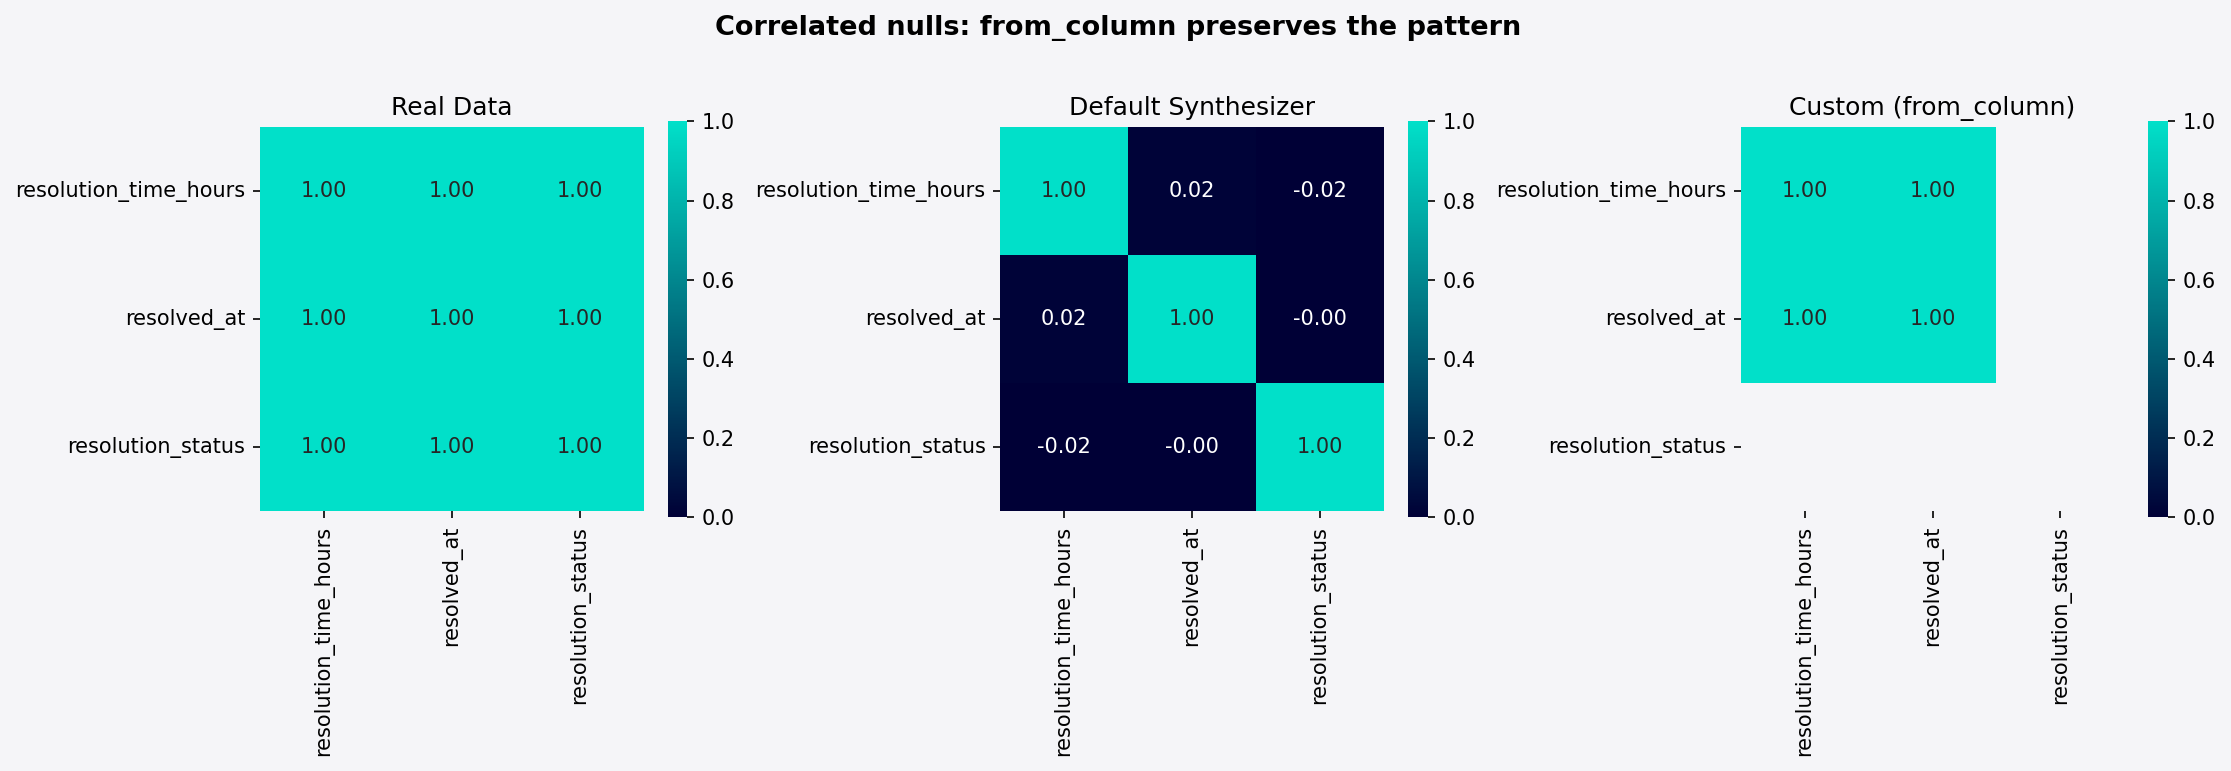

## 12. Measuring Null Fidelity with SDMetrics

SDMetrics provides a `MissingValueSimilarity` metric that scores how well synthetic null rates match real data, from 0.0 (completely different) to 1.0 (identical). This is included in the Quality Report under Column Shapes.

In [20]:
from sdmetrics.single_column import MissingValueSimilarity

# Score each nullable column
for col in data.columns[data.isnull().any()]:
    score = MissingValueSimilarity.compute(
        real_data=data[col],
        synthetic_data=synthetic_data[col]
    )
    print(f'{col:30s} MissingValueSimilarity: {score:.3f}')

customer_email                 MissingValueSimilarity: 1.000
category                       MissingValueSimilarity: 0.986
is_escalated                   MissingValueSimilarity: 0.995
response_time_hours            MissingValueSimilarity: 0.996
resolution_time_hours          MissingValueSimilarity: 0.998
satisfaction_score             MissingValueSimilarity: 0.980
internal_notes_count           MissingValueSimilarity: 0.998
resolved_at                    MissingValueSimilarity: 0.991
resolution_status              MissingValueSimilarity: 0.988
agent_name                     MissingValueSimilarity: 1.000
customer_phone                 MissingValueSimilarity: 1.000
num_reassignments              MissingValueSimilarity: 0.998
customer_notes                 MissingValueSimilarity: 1.000


## 13. Practical Recommendations

### Which mode should I use?

1. **Are nulls in your data meaningful?** (e.g., "not applicable" vs "unknown")
   - No: Use `'random'` (default). Done.
   - Yes: Continue.

2. **Are null patterns correlated across columns?**
   - No: Use `'from_column'` on the meaningful columns.
   - Yes: Use `'from_column'` + `FixedCombinations` or `FixedNullCombinations` (Enterprise) for strict enforcement.

3. **Do you need zero nulls in synthetic output?**
   - Set `missing_value_generation=None` on all relevant columns.
   - Note: categorical/boolean columns always preserve their null rate as a category - you'll need to post-process those manually.

### Checklist

1. **Always inspect preprocessed data** after fitting by calling `synthesizer.preprocess(data)`. Look for unexpected `.is_null` columns and verify the imputed values make sense.

2. **Use `'from_column'`** for `missing_value_generation` when missingness is meaningful and correlated with other features.

3. **Use `'random'`** for `missing_value_generation` when nulls are truly random, or when GaussianCopula is underproducing nulls.

4. **Compare null rates** between real and synthetic data after sampling: `synthetic_data.isnull().mean()` vs `real_data.isnull().mean()`.

5. **Replace placeholders with NaN** before fitting. SDV does not auto-detect `-1`, `999`, `"N/A"`, or similar sentinel values. Also convert empty strings (`""`) to `NaN`.

6. **Use `computer_representation='Int64'`** in metadata for integer columns with nulls to preserve nullable integer types.

7. **Consider `'random'`** for `missing_value_replacement` instead of the default `'mean'`. It avoids creating an artificial spike at the mean value and often produces better synthetic data quality.

8. **Test constraints** on a small data subset first. Null-related constraint errors are among the most commonly filed SDV issues.

> **Multi-table note:** As of SDV v1.16, `HMASynthesizer` supports nullable foreign keys - child rows can exist without a parent relationship. In earlier versions, nullable foreign keys required a dummy parent row workaround. If you're working with multi-table data that has optional relationships, make sure you're on v1.16+.

## Summary

SDV's null handling lives entirely in the RDT preprocessing layer. The synthesizer — whether GaussianCopula, CTGAN, TVAE, or CopulaGAN — never sees a null value. The `NullTransformer` records null proportions, fills them with imputed values, optionally creates binary indicator columns, and reverses the process after generation.

The single most important decision is choosing `missing_value_generation`:
- `'random'` (default) preserves null *proportions* but not *patterns*
- `'from_column'` models null *patterns* and *correlations* but can distort rates
- `None` eliminates nulls entirely from synthetic output

For most use cases, the default works well. Switch to `'from_column'` only when missingness is informative, and always validate null rates afterward.